# TaxoViz — Interactive Exploration Notebook
**Purpose:** Explore k-mer ordination + classifier agreement on a **10k-read subset**.
Run cells one by one, tweak parameters in the CONFIG cell, re-run downstream cells.

**Companion file:** `taxoviz_full.py` — production CLI for the full 15M-read dataset.


In [18]:
# ── CELL 1: CONFIGURATION ─────────────────────────────────────────────────
# Edit these paths and parameters, then run all cells.

CONFIG = {
    # --- Input files ---
    "fastq_path":        "reads/414.SUB.fastq",   # your 10k-read FASTQ
    "metaphlan_sam":     "classifications/metaphlan.sam",          # MetaPhlAn4 --samout output
    "krakenuniq_out":    "classifications/krakenuniq.out",           # KrakenUniq per-read output
    "centrifuger_out":   "classifications/centrifuger.out",          # Centrifuger per-read output
    "taxonomy_dir":      "data/ncbi_taxonomy/",  # dir with nodes.dmp + names.dmp

    # --- k-mer parameters ---
    "k_values":          (4, 6),       # concatenated canonical k-mer features
    "clr_pseudocount":   1.0,          # δ for CLR transform

    # --- PCA ---
    "pca_max_components":    75,        # hard cap on PCA components
    "pca_variance_threshold": 0.75,    # keep enough PCs to explain this fraction

    # --- t-SNE (openTSNE) ---
    "tsne_perplexity":   250,
    "tsne_metric":       "manhattan",  # binny standard
    "tsne_n_iter":       500,
    "tsne_n_jobs":       -1,           # -1 = all cores

    # --- UMAP ---
    "umap_n_neighbors":  100,
    "umap_min_dist":     0.3,
    "umap_metric":       "manhattan",

    # --- Misc ---
    "n_jobs":            -1,           # joblib parallelism
    "random_seed":       42,
}

print("CONFIG loaded.")
print(f"  k_values          : {CONFIG['k_values']}")
print(f"  CLR pseudocount   : {CONFIG['clr_pseudocount']}")
print(f"  PCA max components: {CONFIG['pca_max_components']}")
print(f"  t-SNE perplexity  : {CONFIG['tsne_perplexity']}")
print(f"  UMAP n_neighbors  : {CONFIG['umap_n_neighbors']}")


CONFIG loaded.
  k_values          : (4, 6)
  CLR pseudocount   : 1.0
  PCA max components: 75
  t-SNE perplexity  : 250
  UMAP n_neighbors  : 100


In [3]:
# ── CELL 2: IMPORTS ───────────────────────────────────────────────────────
import sys, os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pickle 
import bz2
# Add the directory containing taxoviz_core.py to the path
# (adjust if you placed it elsewhere)
sys.path.insert(0, os.path.dirname(os.path.abspath("taxoviz_core.py")))
import taxoviz_core as tc

print(f"numpy  {np.__version__}")
print(f"pandas {pd.__version__}")
print(f"matplotlib {matplotlib.__version__}")

# Check optional heavy deps
for pkg in ("openTSNE", "umap", "sklearn", "numba", "joblib"):
    try:
        mod = __import__(pkg)
        ver = getattr(mod, "__version__", "?")
        print(f"  {pkg:12s} {ver}")
    except ImportError:
        print(f"  {pkg:12s} NOT FOUND")


numpy  2.2.6
pandas 2.3.3
matplotlib 3.10.9
  openTSNE     1.0.4
  umap         0.5.12
  sklearn      1.6.1
  numba        0.65.1
  joblib       1.5.3


Loaded 9,993 reads
  Length  min=1,000  median=6,457  max=97,691
  GC mean = 0.466


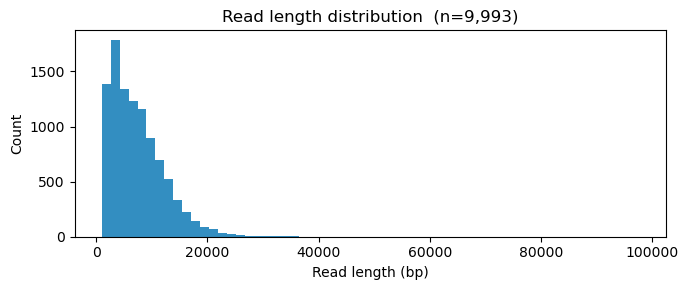

In [4]:
# ── CELL 3: LOAD FASTQ ────────────────────────────────────────────────────
read_ids, sequences = tc.read_fastq_all(CONFIG["fastq_path"])
n_reads = len(read_ids)
read_lens = np.array([len(s) for s in sequences])

print(f"Loaded {n_reads:,} reads")
print(f"  Length  min={read_lens.min():,}  median={int(np.median(read_lens)):,}  "
      f"max={read_lens.max():,}")
print(f"  GC mean = {tc.gc_content(sequences).mean():.3f}")

# Quick length histogram
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(read_lens, bins=60, color="#0072B2", edgecolor="none", alpha=0.8)
ax.set_xlabel("Read length (bp)")
ax.set_ylabel("Count")
ax.set_title(f"Read length distribution  (n={n_reads:,})")
plt.tight_layout()
plt.show()


Loaded 5,730,402 reads
  Length  min=1,000  median=6,425  max=99,958
  GC mean = 0.467


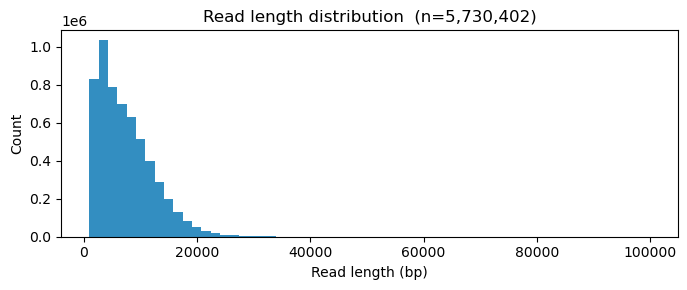

In [ ]:
# ── CELL 3: LOAD FASTQ ────────────────────────────────────────────────────
# статистика по полному FASTQ (не отсемплированный до 100к ридов)
read_ids, sequences = tc.read_fastq_all(CONFIG["fastq_path"])
n_reads = len(read_ids)
read_lens = np.array([len(s) for s in sequences])

print(f"Loaded {n_reads:,} reads")
print(f"  Length  min={read_lens.min():,}  median={int(np.median(read_lens)):,}  "
      f"max={read_lens.max():,}")
print(f"  GC mean = {tc.gc_content(sequences).mean():.3f}")

# Quick length histogram
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(read_lens, bins=60, color="#0072B2", edgecolor="none", alpha=0.8)
ax.set_xlabel("Read length (bp)")
ax.set_ylabel("Count")
ax.set_title(f"Read length distribution  (n={n_reads:,})")
plt.tight_layout()
plt.show()


In [5]:
metphlan_taxdb = pickle.load(bz2.open('/mnt/raid0/Databases/DDTdb/MetaPhlAn4/mpa_vJan25_CHOCOPhlAnSGB_202503.pkl', 'r'))
#with open('marker_to_taxid.tsv', 'w') as f:
#    f.write(str(metphlan_taxdb))

In [6]:
# ── CELL 4: PARSE CLASSIFIER OUTPUTS ─────────────────────────────────────
read_ids_set = set(read_ids)

mark2taxid = tc.build_marker_to_taxid(metphlan_taxdb)

labels_m = tc.parse_metaphlan_sam(CONFIG["metaphlan_sam"],   read_ids_set, mark2taxid)
labels_k = tc.parse_krakenuniq(   CONFIG["krakenuniq_out"],  read_ids_set)
labels_c = tc.parse_centrifuger(  CONFIG["centrifuger_out"], read_ids_set)

def _classified_count(d):
    return sum(1 for v in d.values() if v is not None and v > 0)

print(f"MetaPhlAn4  classified: {_classified_count(labels_m):,} / {n_reads:,} "
      f"({100*_classified_count(labels_m)/n_reads:.1f}%)")
print(f"KrakenUniq  classified: {_classified_count(labels_k):,} / {n_reads:,} "
      f"({100*_classified_count(labels_k)/n_reads:.1f}%)")
print(f"Centrifuger classified: {_classified_count(labels_c):,} / {n_reads:,} "
      f"({100*_classified_count(labels_c)/n_reads:.1f}%)")


MetaPhlAn4  classified: 3,213 / 9,993 (32.2%)
KrakenUniq  classified: 9,256 / 9,993 (92.6%)
Centrifuger classified: 9,871 / 9,993 (98.8%)


In [7]:
# ── CELL 5: TAXONOMY NORMALISATION ───────────────────────────────────────
# Loads NCBI taxonomy and builds the metadata DataFrame.
# Takes ~1-2 min for 10k reads (taxopy tree traversal).

taxdb = tc.load_taxonomy(CONFIG["taxonomy_dir"])

meta = tc.build_metadata_df(
    read_ids, sequences,
    labels_m, labels_k, labels_c,
    taxdb,
)

print(f"Metadata shape: {meta.shape}")
print()
print("Agreement at GENUS level:")
print(meta["agreement_genus"].value_counts().to_string())
print()
print("Agreement at SPECIES level:")
print(meta["agreement_species"].value_counts().to_string())


Metadata shape: (9993, 19)

Agreement at GENUS level:
agreement_genus
KC        5394
K_only    1850
MKC       1500
none       588
C_only     422
M_only     152
MK          70
MC          17

Agreement at SPECIES level:
agreement_species
KC        5574
K_only    1998
MKC        884
C_only     780
none       432
M_only     248
MK          54
MC          23


In [8]:
# ── CELL 6: FEATURE MATRIX  (CLR k-mers + GC z-score) ───────────────────
# For 10k reads this takes ~10-30 s depending on whether Numba is available.

X = tc.build_feature_matrix(
    sequences,
    k_values=CONFIG["k_values"],
    pseudocount=CONFIG["clr_pseudocount"],
    n_jobs=CONFIG["n_jobs"],
)

print(f"Feature matrix shape : {X.shape}")
print(f"  Expected           : ({n_reads}, 2217)  [136 + 2080 CLR + 1 GC]")
print(f"  dtype              : {X.dtype}")
print(f"  RAM                : {X.nbytes / 1e6:.1f} MB")
print(f"  Any NaN/Inf        : {np.isnan(X).any() or np.isinf(X).any()}")


Feature matrix shape : (9993, 2217)
  Expected           : (9993, 2217)  [136 + 2080 CLR + 1 GC]
  dtype              : float32
  RAM                : 88.6 MB
  Any NaN/Inf        : False


PCA: 75 components explain 54.5% variance  (threshold 75%)


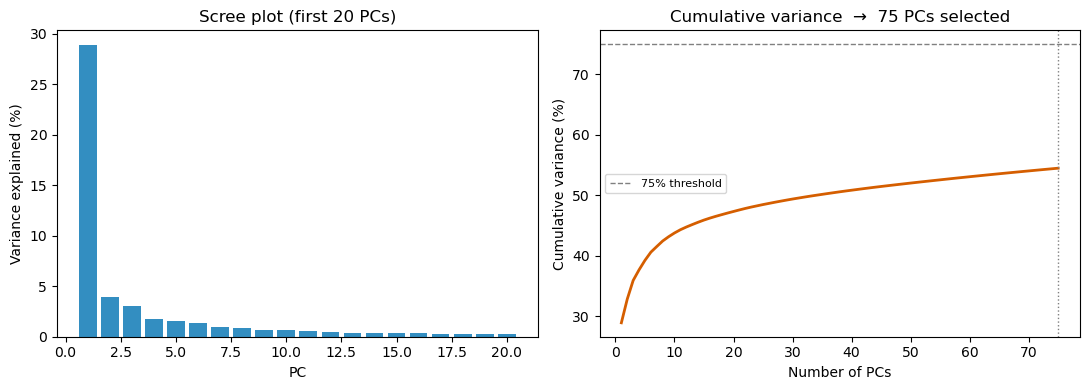

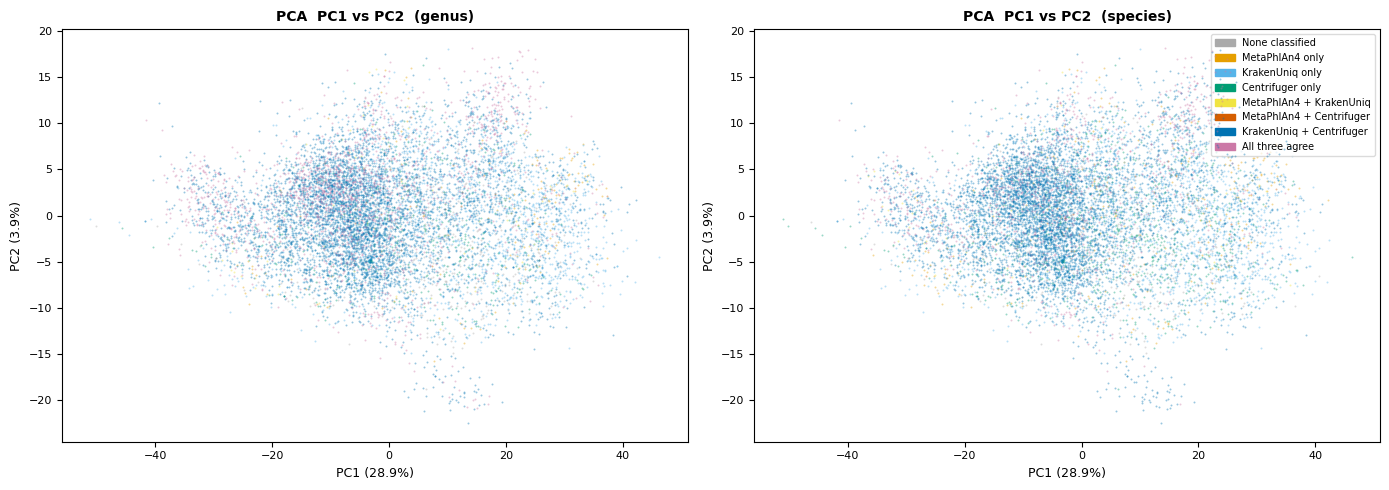

In [9]:
# ── CELL 7: PCA ──────────────────────────────────────────────────────────
from sklearn.decomposition import PCA

pca_full = PCA(
    n_components=CONFIG["pca_max_components"],
    random_state=CONFIG["random_seed"],
)
X_pca_full = pca_full.fit_transform(X)

# Choose number of components to explain pca_variance_threshold
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components = int(np.searchsorted(cumvar, CONFIG["pca_variance_threshold"]) + 1)
n_components = min(n_components, CONFIG["pca_max_components"])
X_pca = X_pca_full[:, :n_components]

print(f"PCA: {n_components} components explain "
      f"{100*cumvar[n_components-1]:.1f}% variance  "
      f"(threshold {100*CONFIG['pca_variance_threshold']:.0f}%)")

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(range(1, 21),
            pca_full.explained_variance_ratio_[:20] * 100,
            color="#0072B2", alpha=0.8)
axes[0].set_xlabel("PC")
axes[0].set_ylabel("Variance explained (%)")
axes[0].set_title("Scree plot (first 20 PCs)")

axes[1].plot(range(1, len(cumvar) + 1), cumvar * 100, color="#D55E00", lw=2)
axes[1].axhline(CONFIG["pca_variance_threshold"] * 100,
                color="grey", ls="--", lw=1, label=f"{CONFIG['pca_variance_threshold']*100:.0f}% threshold")
axes[1].axvline(n_components, color="grey", ls=":", lw=1)
axes[1].set_xlabel("Number of PCs")
axes[1].set_ylabel("Cumulative variance (%)")
axes[1].set_title(f"Cumulative variance  →  {n_components} PCs selected")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# PC1 vs PC2 coloured by agreement (genus)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, level in zip(axes, ("genus", "species")):
    tc.scatter_ordination(
        ax, X_pca_full[:, :2], meta[f"agreement_{level}"],
        title=f"PCA  PC1 vs PC2  ({level})",
        xlabel=f"PC1 ({100*pca_full.explained_variance_ratio_[0]:.1f}%)",
        ylabel=f"PC2 ({100*pca_full.explained_variance_ratio_[1]:.1f}%)",
    )
handles = tc.make_legend_handles()
axes[1].legend(handles=handles, fontsize=7, loc="upper right",
               framealpha=0.7, markerscale=3)
plt.tight_layout()
plt.show()


--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, metric='manhattan', n_jobs=-1, perplexity=250,
     random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 750 nearest neighbors using Annoy approximate search using manhattan distance...
   --> Time elapsed: 5.06 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 2.75 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.01 seconds
===> Running optimization with exaggeration=12.00, lr=832.75 for 250 iterations...
Iteration   50, KL divergence 3.1814, 50 iterations in 3.8163 sec
Iteration  100, KL divergence 3.1698, 50 iterations in 3.6781 sec
Iteration  150, KL divergence 3.1692, 50 iterations in 3.8221 sec
Iteration  200, KL divergence 3.1692, 50 iterations in 3.9113 sec
Iteration  250, KL divergence 3.1693, 50 iterations in 3.9775 sec
   --> Time elapsed: 19.21 seconds
==

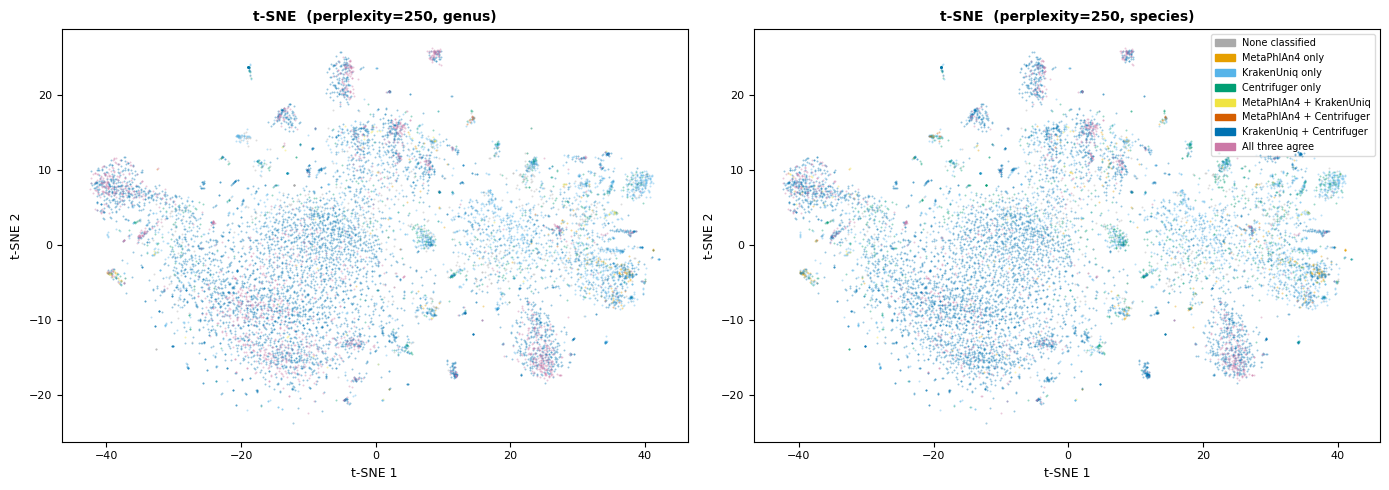

In [19]:
# ── CELL 8: t-SNE  (openTSNE) ────────────────────────────────────────────
# For 10k reads: ~30-90 s.
# Tweak tsne_perplexity in CONFIG and re-run this cell to compare.

from openTSNE import TSNE

tsne = TSNE(
    perplexity=CONFIG["tsne_perplexity"],
    metric=CONFIG["tsne_metric"],
    n_iter=CONFIG["tsne_n_iter"],
    n_jobs=CONFIG["tsne_n_jobs"],
    random_state=CONFIG["random_seed"],
    verbose=True,
)
X_tsne = tsne.fit(X_pca)

print(f"t-SNE embedding shape: {X_tsne.shape}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, level in zip(axes, ("genus", "species")):
    tc.scatter_ordination(
        ax, X_tsne, meta[f"agreement_{level}"],
        title=f"t-SNE  (perplexity={CONFIG['tsne_perplexity']}, {level})",
        xlabel="t-SNE 1", ylabel="t-SNE 2",
    )
handles = tc.make_legend_handles()
axes[1].legend(handles=handles, fontsize=7, loc="upper right",
               framealpha=0.7, markerscale=3)
plt.tight_layout()
plt.show()


UMAP(metric='manhattan', min_dist=0.3, n_jobs=1, n_neighbors=100, random_state=42, verbose=True)
Wed Jun 10 20:41:02 2026 Construct fuzzy simplicial set
Wed Jun 10 20:41:02 2026 Finding Nearest Neighbors
Wed Jun 10 20:41:02 2026 Building RP forest with 10 trees
Wed Jun 10 20:41:02 2026 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	 4  /  13
	Stopping threshold met -- exiting after 4 iterations
Wed Jun 10 20:41:10 2026 Finished Nearest Neighbor Search
Wed Jun 10 20:41:10 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Wed Jun 10 20:41:37 2026 Finished embedding
UMAP embedding shape: (9993, 2)


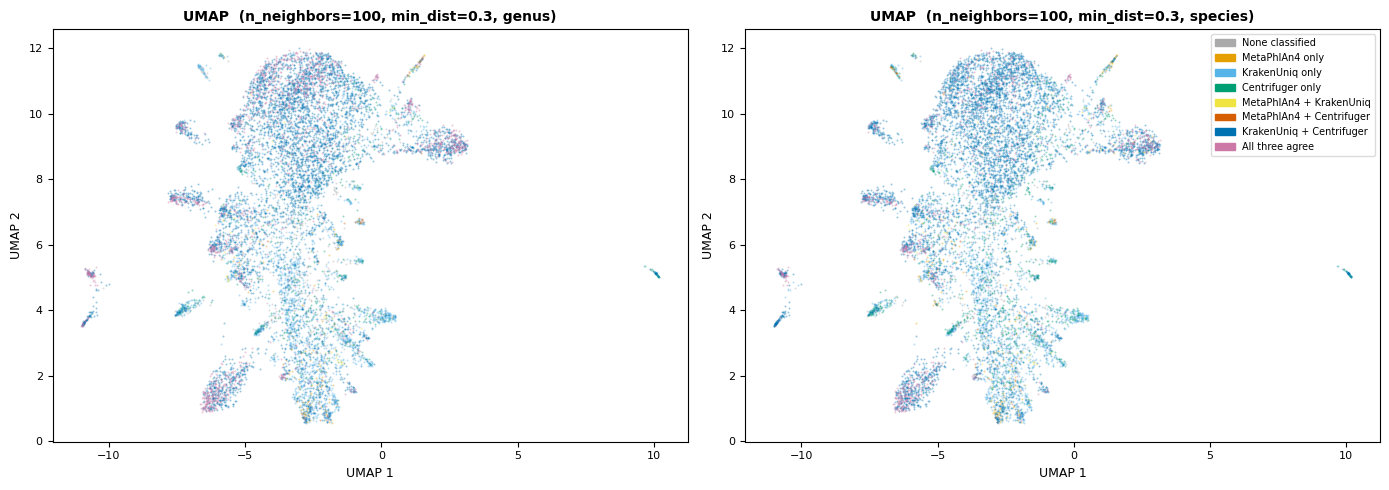

In [20]:
# ── CELL 9: UMAP ─────────────────────────────────────────────────────────
# For 10k reads: ~10-30 s.
# Tweak umap_n_neighbors / umap_min_dist in CONFIG and re-run.

import umap

reducer = umap.UMAP(
    n_neighbors=CONFIG["umap_n_neighbors"],
    min_dist=CONFIG["umap_min_dist"],
    metric=CONFIG["umap_metric"],
    random_state=CONFIG["random_seed"],
    verbose=True,
)
X_umap = reducer.fit_transform(X_pca)

print(f"UMAP embedding shape: {X_umap.shape}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, level in zip(axes, ("genus", "species")):
    tc.scatter_ordination(
        ax, X_umap, meta[f"agreement_{level}"],
        title=f"UMAP  (n_neighbors={CONFIG['umap_n_neighbors']}, "
              f"min_dist={CONFIG['umap_min_dist']}, {level})",
        xlabel="UMAP 1", ylabel="UMAP 2",
    )
handles = tc.make_legend_handles()
axes[1].legend(handles=handles, fontsize=7, loc="upper right",
               framealpha=0.7, markerscale=3)
plt.tight_layout()
plt.show()


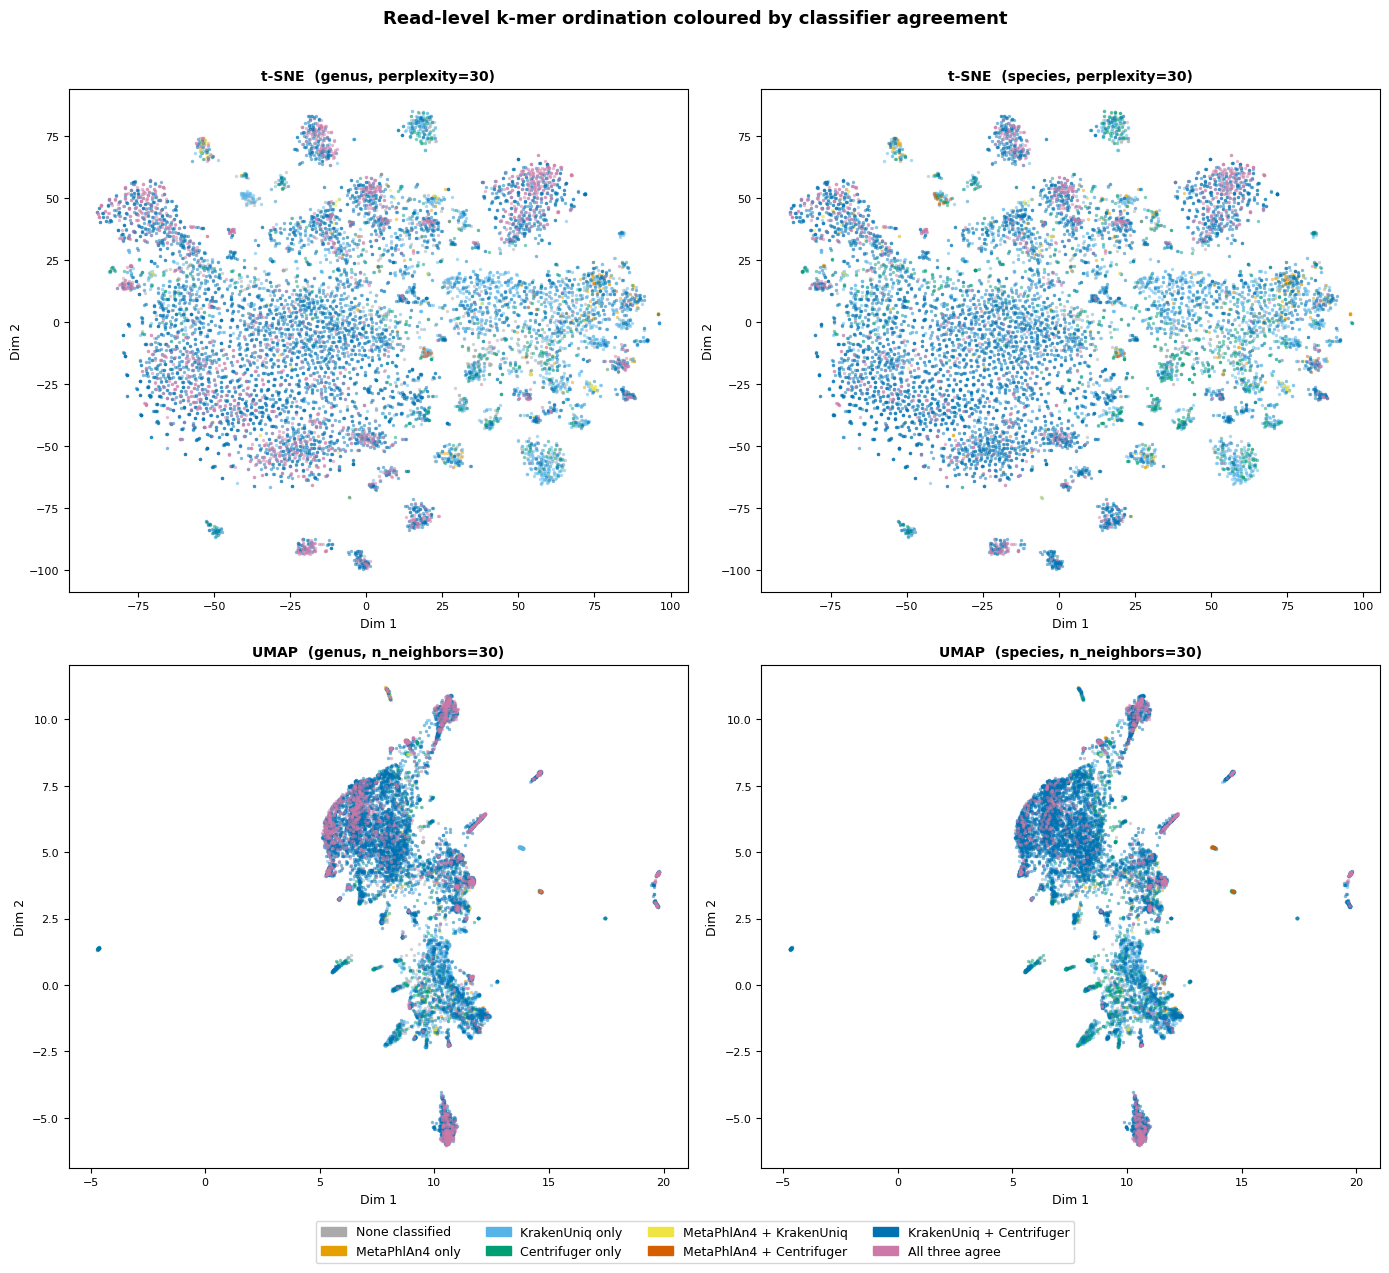

Saved: taxoviz_static.svg  taxoviz_static.png


In [14]:
# ── CELL 10: COMBINED 2×2 STATIC FIGURE ─────────────────────────────────
# t-SNE (top) and UMAP (bottom) × genus (left) and species (right)
# Saved as SVG for publication quality.

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Read-level k-mer ordination coloured by classifier agreement",
             fontsize=13, fontweight="bold", y=1.01)

panels = [
    (axes[0, 0], X_tsne, "genus",   f"t-SNE  (genus, perplexity={CONFIG['tsne_perplexity']})"),
    (axes[0, 1], X_tsne, "species", f"t-SNE  (species, perplexity={CONFIG['tsne_perplexity']})"),
    (axes[1, 0], X_umap, "genus",   f"UMAP  (genus, n_neighbors={CONFIG['umap_n_neighbors']})"),
    (axes[1, 1], X_umap, "species", f"UMAP  (species, n_neighbors={CONFIG['umap_n_neighbors']})"),
]

for ax, coords, level, title in panels:
    tc.scatter_ordination(
        ax, coords, meta[f"agreement_{level}"],
        title=title, xlabel="Dim 1", ylabel="Dim 2",
        alpha=0.5, s=6.0,
    )

handles = tc.make_legend_handles()
fig.legend(handles=handles, loc="lower center", ncol=4,
           fontsize=9, framealpha=0.8,
           bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig("taxoviz_static.svg", bbox_inches="tight", dpi=150)
plt.savefig("taxoviz_static.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: taxoviz_static.svg  taxoviz_static.png")


In [21]:
# ── CELL 11: INTERACTIVE HTML  (Plotly WebGL) ────────────────────────────
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def _make_traces(coords, agreement_series, level):
    traces = []
    for cat in tc.CATEGORIES:
        mask = (agreement_series == cat).values
        if mask.sum() == 0:
            continue
        traces.append(go.Scattergl(
            x=coords[mask, 0], y=coords[mask, 1],
            mode="markers",
            marker=dict(size=3, color=tc.COLORS[cat], opacity=0.6),
            name=tc.LABEL_NAMES[cat],
            text=[
                f"read: {rid}<br>len: {meta.loc[rid,'read_len']}<br>"
                f"gc: {meta.loc[rid,'gc']:.2f}<br>"
                f"M: {meta.loc[rid,f'metaphlan_{level}_name']}<br>"
                f"K: {meta.loc[rid,f'krakenuniq_{level}_name']}<br>"
                f"C: {meta.loc[rid,f'centrifuger_{level}_name']}"
                for rid in meta.index[mask]
            ],
            hovertemplate="%{text}<extra></extra>",
            legendgroup=cat,
            showlegend=True,
        ))
    return traces

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        "t-SNE genus", "t-SNE species",
        "UMAP genus",  "UMAP species",
    ],
    shared_xaxes=False,
)

for row, (coords, method) in enumerate([(X_tsne, "tsne"), (X_umap, "umap")], start=1):
    for col, level in enumerate(["genus", "species"], start=1):
        for trace in _make_traces(coords, meta[f"agreement_{level}"], level):
            trace.showlegend = (row == 1 and col == 1)
            fig.add_trace(trace, row=row, col=col)

fig.update_layout(
    title="TaxoViz — k-mer ordination × classifier agreement",
    height=900, width=1200,
    legend=dict(itemsizing="constant"),
)
fig.update_traces(marker_size=3)

fig.write_html("taxoviz_interactive.html")
print("Saved: taxoviz_interactive.html")
fig.show()


Saved: taxoviz_interactive.html


In [13]:
# ── CELL 12: AGREEMENT STATISTICS TABLE ──────────────────────────────────
rows = []
for level in ("genus", "species"):
    vc = meta[f"agreement_{level}"].value_counts()
    for cat in tc.CATEGORIES:
        n = vc.get(cat, 0)
        rows.append({
            "level":    level,
            "category": cat,
            "label":    tc.LABEL_NAMES[cat],
            "count":    n,
            "pct":      f"{100*n/len(meta):.1f}%",
        })

stats = pd.DataFrame(rows)
print(stats.to_string(index=False))
stats.to_csv("taxoviz_agreement_stats.csv", index=False)
print("\nSaved: taxoviz_agreement_stats.csv")


  level category                    label  count   pct
  genus     none          None classified    588  5.9%
  genus   M_only          MetaPhlAn4 only    152  1.5%
  genus   K_only          KrakenUniq only   1850 18.5%
  genus   C_only         Centrifuger only    422  4.2%
  genus       MK  MetaPhlAn4 + KrakenUniq     70  0.7%
  genus       MC MetaPhlAn4 + Centrifuger     17  0.2%
  genus       KC KrakenUniq + Centrifuger   5394 54.0%
  genus      MKC          All three agree   1500 15.0%
species     none          None classified    432  4.3%
species   M_only          MetaPhlAn4 only    248  2.5%
species   K_only          KrakenUniq only   1998 20.0%
species   C_only         Centrifuger only    780  7.8%
species       MK  MetaPhlAn4 + KrakenUniq     54  0.5%
species       MC MetaPhlAn4 + Centrifuger     23  0.2%
species       KC KrakenUniq + Centrifuger   5574 55.8%
species      MKC          All three agree    884  8.8%

Saved: taxoviz_agreement_stats.csv


In [ ]:
# ── CELL 13: PARAMETER SWEEP HELPER ──────────────────────────────────────
# Quick visual comparison of different perplexity / n_neighbors values.
# Re-run this cell after changing the lists below.

from openTSNE import TSNE
import umap

PERPLEXITIES  = [15, 30, 50]   # ← edit
N_NEIGHBORS   = [15, 30, 50]   # ← edit
LEVEL         = "genus"         # ← "genus" or "species"

fig, axes = plt.subplots(
    2, len(PERPLEXITIES),
    figsize=(5 * len(PERPLEXITIES), 10),
)

for col, perp in enumerate(PERPLEXITIES):
    emb = TSNE(
        perplexity=perp, metric=CONFIG["tsne_metric"],
        n_iter=CONFIG["tsne_n_iter"], n_jobs=CONFIG["tsne_n_jobs"],
        random_state=CONFIG["random_seed"],
    ).fit(X_pca)
    tc.scatter_ordination(
        axes[0, col], emb, meta[f"agreement_{LEVEL}"],
        title=f"t-SNE perplexity={perp}", xlabel="t-SNE 1", ylabel="t-SNE 2",
    )

for col, nn in enumerate(N_NEIGHBORS):
    emb = umap.UMAP(
        n_neighbors=nn, min_dist=CONFIG["umap_min_dist"],
        metric=CONFIG["umap_metric"], random_state=CONFIG["random_seed"],
    ).fit_transform(X_pca)
    tc.scatter_ordination(
        axes[1, col], emb, meta[f"agreement_{LEVEL}"],
        title=f"UMAP n_neighbors={nn}", xlabel="UMAP 1", ylabel="UMAP 2",
    )

handles = tc.make_legend_handles()
fig.legend(handles=handles, loc="lower center", ncol=4,
           fontsize=8, bbox_to_anchor=(0.5, -0.03))
plt.suptitle(f"Parameter sweep  ({LEVEL} level)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:
# ── CELL 14: COLOUR BY READ LENGTH AND GC ────────────────────────────────
# Useful for spotting whether diffuse clouds correlate with short reads or
# unusual GC content (error-enriched reads often have lower GC).

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (coords, method) in enumerate([(X_tsne, "t-SNE"), (X_umap, "UMAP")]):
    for col, (values, label, cmap) in enumerate([
        (meta["read_len"].values, "Read length (bp)", "viridis"),
        (meta["gc"].values,       "GC fraction",      "RdYlBu"),
    ]):
        sc = axes[row, col].scatter(
            coords[:, 0], coords[:, 1],
            c=values, cmap=cmap, s=2, alpha=0.5,
            linewidths=0, rasterized=True,
        )
        plt.colorbar(sc, ax=axes[row, col], shrink=0.8, label=label)
        axes[row, col].set_title(f"{method} — {label}", fontsize=10)
        axes[row, col].set_xlabel("Dim 1", fontsize=9)
        axes[row, col].set_ylabel("Dim 2", fontsize=9)

plt.tight_layout()
plt.show()
